# Group Assignment #3: Clean Notebook

**Author:** Abigail Adams 

**Group:** Abigail Adams, Jasmine Law, Caleb Huang and Ronald Tien Giang

**Notebook Purpose:** This notebook explores modes of transportation used by San Francisco residents. The purpose of this notebook is to identify the percentage of people in San Francisco using public transportation and the characterisitcs of MUNI riders. 

**Data Sources:** 
1. American Community Survey [(ACS)](https://www.socialexplorer.com/reports/socialexplorer/en/report/c529bd86-ffc7-11ef-8f8b-e71b92843544) 5-year estimate (2019-2023)
2. MUNI ridership data from the San Francisco Municipal Transportation Agency (SFMTA) from 2020 to present 


**Function or Loop:** For the function or the loop, I am going to make a list of the priority neighborhoods, and run a loop to tell me how much of the population is under 18, perhaps using the proportion or percentage of the entire SF minor population. This will be useful because it will tell us that how many students are impacted by factors that impact the quality of schools in their area, the resources in their neighborhoods, and their general transportation access.  use function to create maps that shows which census tracts that have a percentage of poverty that is greater than 20%

**Steps:** 

* DONE - First, I will clean and run summary statistics on the major modes of transportation using the ACS data.
* Then, I will examine the major demographic characteristics of people using public transportation, such as race, income, and disability status, private vehicle access. (out of everyone that uses public transportation, how many of those people are poor, or have children, or etc)
* Then, I am going to map the equity priority neighbhooods from [SFMTA](https://data.sfgov.org/Transportation/Equity-Strategy-Neighborhoods/f8bh-m8ez/about_data). I am going to map this data to get a general sense of their locations, create a list out of these neighbohoods, and then create a loop that will tell me the number of people under the age of 18 in these neighborhoods. 

## Part 1: ACS  
To determine the most commonly used modes of transportation, we will use data from the American Community Survey (ACS), specifically the 5-year estimate from 2017-2023. This is the most recent ACS data available. The data is scaled by census tracts. 

**Variables Included:**

1. Means of Transportation to Work for Workers 16 Years and Over
2. Total Population
3. Age (Short version)
4. Race
5. Hispanic or Latino by Race
6. Housing Units by Families and Presence of Own Children
7. Median Household Income (In 2023 Inflation Adjusted Dollars)
8. Median Family Income (In 2023 Inflation Adjusted Dollars)
10. Housing Units by Vehicles Available


In [1]:
# import necessary packages
# to read and wrangle data
import pandas as pd

# to import data from LA Data portal
from sodapy import Socrata

# to create spatial data
import geopandas as gpd

# for basemaps
import contextily as ctx

# For spatial statistics
import esda
from esda.moran import Moran, Moran_Local

import splot
from splot.esda import moran_scatterplot, plot_moran, lisa_cluster,plot_moran_simulation

import libpysal as lps

# Graphics
import matplotlib.pyplot as plt
import plotly.express as px

In [43]:
# import acs data
acs = pd.read_csv("data/up221_wk7_data.csv")

# verify download and check dimensions
acs.shape

(245, 153)

The ACS dataset has 245 rows and 153 columns. Each row is a census tract and each column represents a variable. Our next step is to cleaning the dataset to properly name the columns. 

In [84]:
# check first 5 rows of data 
acs.head(1)

,FIPS,Qualifying Name,State Postal Abbreviation,Summary Level,Geographic Component,US,Census Region,Census Division,State (FIPS Code),County of current residence,...,Occupied Housing Units: 2 Vehicles Available,Occupied Housing Units: 3 Vehicles Available,Occupied Housing Units: 4 Vehicles Available,Occupied Housing Units: 5 or More Vehicles Available,% Occupied Housing Units: No Vehicle Available,% Occupied Housing Units: 1 Vehicle Available,% Occupied Housing Units: 2 Vehicles Available,% Occupied Housing Units: 3 Vehicles Available,% Occupied Housing Units: 4 Vehicles Available,% Occupied Housing Units: 5 or More Vehicles Available
1,06075010101,"Census Tract 101.01, San Francisco County, Cal...",ca,140,00,NaN,NaN,NaN,06,075,...,102,0,0,0,37.87,53.71,8.42,0,0,0


**Column Names**

Note that the columns of this dataset are already named according to their variables. The typical variable names are located in row 0. We will ensure to remove Row 0 from our analysis because the values are different and can change the variable's data type. 

This prevents us from having to rename over 100 columns, but may affect the data types of each columns. 

In [48]:
# remove row 0
acs.drop(acs.head(1).index,inplace=True)

# check
acs.head(2)

,FIPS,Qualifying Name,State Postal Abbreviation,Summary Level,Geographic Component,US,Census Region,Census Division,State (FIPS Code),County of current residence,...,Occupied Housing Units: 2 Vehicles Available,Occupied Housing Units: 3 Vehicles Available,Occupied Housing Units: 4 Vehicles Available,Occupied Housing Units: 5 or More Vehicles Available,% Occupied Housing Units: No Vehicle Available,% Occupied Housing Units: 1 Vehicle Available,% Occupied Housing Units: 2 Vehicles Available,% Occupied Housing Units: 3 Vehicles Available,% Occupied Housing Units: 4 Vehicles Available,% Occupied Housing Units: 5 or More Vehicles Available
1,06075010101,"Census Tract 101.01, San Francisco County, Cal...",ca,140,00,NaN,NaN,NaN,06,075,...,102,0,0,0,37.87,53.71,8.42,0,0,0
2,06075010102,"Census Tract 101.02, San Francisco County, Cal...",ca,140,00,NaN,NaN,NaN,06,075,...,148,10,0,0,33.41,49.17,16.32,1.1,0,0


In [49]:
# make object for column names, too long to print
column_names = acs.columns.tolist()

# print
column_names

['FIPS',
 'Qualifying Name',
 'State Postal Abbreviation',
 'Summary Level',
 'Geographic Component',
 'US',
 'Census Region',
 'Census Division',
 'State (FIPS Code)',
 'County of current residence',
 'County Subdivision (FIPS)',
 'Place (FIPS Code)',
 'Census Tract',
 'Block Group',
 'Consolidated City',
 'American Indian Area/Alaska Native Area/Hawaiian Home Land (Census)',
 'American Indian Area/Alaska Native Area/Hawaiian Home Land (FIPS)',
 'American Indian Trust Land/Hawaiian Home Land Indicator',
 'American Indian Tribal Subdivision (FIPS)',
 'Alaska Native Regional Corporation (FIPS)',
 'Metropolitan and Micropolitan Statistical Area',
 'Combined Statistical Area',
 'Metropolitan Statistical Area Metropolitan Division',
 'Metropolitan Area Central City',
 'Metropolitan/Micropolitan Indicator Flag',
 'New England City and Town Area',
 'New England City and Town Combined Statistical Area',
 'New England City and Town Area Division',
 'Urban Area',
 'Current Congressional Distric

**Column Removal**

Now, we will be removing columns that will not be used for this notebook. While there are only 8 variables, the columns also make up each individual answer option. We only need about half of these columns to get information that is useful for this project. 

At a minimum, we will be removing:

* Columns 2-15 because they are geographic components that make up the `FIPS` column
* Empty columns (all NA values)

In [50]:
# print columns with no values
na_columns = acs.columns[acs.isnull().all()].tolist()

na_columns

#check = acs.dropna(axis=1,how="all")

['US',
 'Census Region',
 'Census Division',
 'County Subdivision (FIPS)',
 'Place (FIPS Code)',
 'Block Group',
 'Consolidated City',
 'American Indian Area/Alaska Native Area/Hawaiian Home Land (Census)',
 'American Indian Area/Alaska Native Area/Hawaiian Home Land (FIPS)',
 'American Indian Trust Land/Hawaiian Home Land Indicator',
 'American Indian Tribal Subdivision (FIPS)',
 'Alaska Native Regional Corporation (FIPS)',
 'Metropolitan and Micropolitan Statistical Area',
 'Combined Statistical Area',
 'Metropolitan Statistical Area Metropolitan Division',
 'Metropolitan Area Central City',
 'Metropolitan/Micropolitan Indicator Flag',
 'New England City and Town Area',
 'Urban Area',
 'Current Congressional District ***',
 'State Legislative District Upper',
 'State Legislative District Lower',
 'ZIP Code Tabulation Area (3-digit)',
 '5-digit ZIP Code Tabulation Area',
 'Subminor Civil Division (FIPS)',
 'State-School District (Elementary)',
 'State-School District (Secondary)',
 'S

The object `na_columns` tells us which columns to drop. 

In [51]:
# remove columns with na from object 'na_columns' + unnecessary geo columns
acs_trim = acs.drop(['Qualifying Name',
 'State Postal Abbreviation',
 'Summary Level',
 'Geographic Component',
 'US',
 'Census Region',
 'Census Division',
 'State (FIPS Code)',
 'County of current residence',
 'County Subdivision (FIPS)',
 'Place (FIPS Code)',
 #'Census Tract',
 'Block Group',
 'Consolidated City',
 'American Indian Area/Alaska Native Area/Hawaiian Home Land (Census)',
 'American Indian Area/Alaska Native Area/Hawaiian Home Land (FIPS)',
 'American Indian Trust Land/Hawaiian Home Land Indicator',
 'American Indian Tribal Subdivision (FIPS)',
 'Alaska Native Regional Corporation (FIPS)',
 'Metropolitan and Micropolitan Statistical Area',
 'Combined Statistical Area',
 'Metropolitan Statistical Area Metropolitan Division',
 'Metropolitan Area Central City',
 'Metropolitan/Micropolitan Indicator Flag',
 'New England City and Town Area',
 'New England City and Town Combined Statistical Area',
 'New England City and Town Area Division',
 'Urban Area',
 'Current Congressional District ***',
 'State Legislative District Upper',
 'State Legislative District Lower',
 'ZIP Code Tabulation Area (3-digit)',
 '5-digit ZIP Code Tabulation Area',
 'Subminor Civil Division (FIPS)',
 'State-School District (Elementary)',
 'State-School District (Secondary)',
 'State-School District (Unified)',
 'Urban/Rural',
 'Principal City Indicator',
 'Public Use Microdata Area – File',
 'Geographic Identifier',
 #'Area Name',
 'Tribal Tract',
 'Tribal Block Group',
 'Place (State FIPS + Place FIPS)', 'Total Population:',], axis=1)

# check 
print(acs_trim.columns)

Index(['FIPS', 'Census Tract', 'Area Name', 'Workers 16 Years and Over:',
       'Workers 16 Years and Over: Car, Truck, or Van',
       'Workers 16 Years and Over: Drove Alone',
       'Workers 16 Years and Over: Carpooled',
       'Workers 16 Years and Over: Public Transportation (Includes Taxicab)',
       'Workers 16 Years and Over: Motorcycle',
       'Workers 16 Years and Over: Bicycle',
       ...
       'Occupied Housing Units: 2 Vehicles Available',
       'Occupied Housing Units: 3 Vehicles Available',
       'Occupied Housing Units: 4 Vehicles Available',
       'Occupied Housing Units: 5 or More Vehicles Available',
       '% Occupied Housing Units: No Vehicle Available',
       '% Occupied Housing Units: 1 Vehicle Available',
       '% Occupied Housing Units: 2 Vehicles Available',
       '% Occupied Housing Units: 3 Vehicles Available',
       '% Occupied Housing Units: 4 Vehicles Available',
       '% Occupied Housing Units: 5 or More Vehicles Available'],
      dtype='o

## Next steps for ACS

1. DONE remove columns 1-47 (show why they were removed through either being completely empty or unnecesary geographic components 
2. DONE remove census tracts where the total population is 0
3. DONE connect geojson component to graph (week 3 census)
4. consolidate columns with every answer option (race to % non white, vehicles availaible to < 2 vehicles, etc) 

In [8]:
# remove columns
#acs_trim = acs.drop(acs.columns[1:46], axis=1)

In [52]:
# check new shape 
acs_trim.shape

(244, 109)

There are now 109 columns. All of these columns may not be necessary, but we are leaving them for now because we may need them later. 

## Trimming Rows
First, we will be verifying the data types of the variables left. While importing the data with column names included made data cleaning easier, the row of data (previously row 0) with the real variable changed the data types to object. This prevents us from conducting numeric extractions or sorting as we usually would. To combat this, we are changing the datatypes to numeric as applicable using a function.   

In [ ]:
Now, we are going to convert the data types back to their original forms because they all changed to object from the inclusion of the columns names in row 0 originally. 

In [54]:
# get info about data types 
acs_trim.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 1 to 244
Data columns (total 109 columns):
 #    Column                                                                                                                                                       Non-Null Count  Dtype 
---   ------                                                                                                                                                       --------------  ----- 
 0    FIPS                                                                                                                                                         244 non-null    object
 1    Census Tract                                                                                                                                                 244 non-null    object
 2    Area Name                                                                                                                                       

,FIPS,Census Tract,Area Name,Workers 16 Years and Over:,"Workers 16 Years and Over: Car, Truck, or Van",Workers 16 Years and Over: Drove Alone,Workers 16 Years and Over: Carpooled,Workers 16 Years and Over: Public Transportation (Includes Taxicab),Workers 16 Years and Over: Motorcycle,Workers 16 Years and Over: Bicycle,...,Occupied Housing Units: 2 Vehicles Available,Occupied Housing Units: 3 Vehicles Available,Occupied Housing Units: 4 Vehicles Available,Occupied Housing Units: 5 or More Vehicles Available,% Occupied Housing Units: No Vehicle Available,% Occupied Housing Units: 1 Vehicle Available,% Occupied Housing Units: 2 Vehicles Available,% Occupied Housing Units: 3 Vehicles Available,% Occupied Housing Units: 4 Vehicles Available,% Occupied Housing Units: 5 or More Vehicles Available
1,06075010101,010101,Census Tract 101.01,1159,159,153,6,280,0,44,...,102,0,0,0,37.87,53.71,8.42,0,0,0
2,06075010102,010102,Census Tract 101.02,855,266,240,26,186,0,16,...,148,10,0,0,33.41,49.17,16.32,1.1,0,0


In [64]:
# make copy before converting 
trim = acs_trim.copy()

# convert data types to INT and drop columns with all NA values 
for col in trim.columns:
    if trim[col].dtype == 'object':
        trim[col] = pd.to_numeric(trim[col], errors='coerce').dropna(how='all').astype(int)

# verify
trim.dtypes

FIPS                                                        int64
Census Tract                                                int64
Area Name                                                 float64
Workers 16 Years and Over:                                  int64
Workers 16 Years and Over: Car, Truck, or Van               int64
                                                           ...   
% Occupied Housing Units: 1 Vehicle Available             float64
% Occupied Housing Units: 2 Vehicles Available            float64
% Occupied Housing Units: 3 Vehicles Available            float64
% Occupied Housing Units: 4 Vehicles Available            float64
% Occupied Housing Units: 5 or More Vehicles Available    float64
Length: 109, dtype: object

Now that the data types have converted to their normal types, we can continue data cleaning. 

## Add Geographic element for mapping 

Now, we are going to merge our cleaned dataframe to the geojson version of SF's census tracts, allowing us to map this data. We will merge on the `FIPS` column. 

In [22]:
# import 
tracts = gpd.read_file("data/sf_2020_censusTract_data.geojson")

# check
tracts.head(1)

,name,intptlon,awater,mtfcc,aland,namelsad,tractce,statefp,data_loaded_at,intptlat,funcstat,countyfp,data_as_of,geoid,geometry
0,9805.01,-122.4193463,9769.0,G5020,1471536.0,Census Tract 9805.01,980501,06,2022-03-04,+37.7162081,S,075,2021-02-01,06075980501,"MULTIPOLYGON (((-122.42722 37.71555, -122.4271..."


In [23]:
# check shape 
tracts.shape

(244, 15)

There are 244 rows (matching our data) and 15 columns. We need to remove all columns expect for `geo_id` (aka FIPS) and `geometry`, which allows us to map. These are the last two columns. 

In [65]:
# import 
tracts = gpd.read_file("data/sf_2020_censusTract_data.geojson")

# check 
tracts.head(2)

,name,intptlon,awater,mtfcc,aland,namelsad,tractce,statefp,data_loaded_at,intptlat,funcstat,countyfp,data_as_of,geoid,geometry
0,9805.01,-122.4193463,9769.0,G5020,1471536.0,Census Tract 9805.01,980501,06,2022-03-04,+37.7162081,S,075,2021-02-01,06075980501,"MULTIPOLYGON (((-122.42722 37.71555, -122.4271..."
1,171.02,-122.4504754,0.0,G5020,294894.0,Census Tract 171.02,017102,06,2022-03-04,+37.7654353,S,075,2021-02-01,06075017102,"MULTIPOLYGON (((-122.45321 37.76825, -122.4516..."


In [66]:
# remove extra columns
tracts_trim = tracts.drop(tracts.columns[0:13], axis=1)

# check 
tracts_trim

,geoid,geometry
0,06075980501,"MULTIPOLYGON (((-122.42722 37.71555, -122.4271..."
1,06075017102,"MULTIPOLYGON (((-122.45321 37.76825, -122.4516..."
2,06075012302,"MULTIPOLYGON (((-122.415 37.78745, -122.41335 ..."
3,06075016801,"MULTIPOLYGON (((-122.43235 37.77378, -122.4308..."
4,06075011902,"MULTIPOLYGON (((-122.41246 37.79163, -122.4117..."
...,...,...
239,06075020201,"MULTIPOLYGON (((-122.42646 37.76627, -122.4252..."
240,06075061508,"MULTIPOLYGON (((-122.39362 37.78308, -122.3928..."
241,06075013001,"MULTIPOLYGON (((-122.43075 37.79865, -122.4291..."
242,06075010201,"MULTIPOLYGON (((-122.42484 37.80227, -122.4246..."


In [67]:
# rename 'geoid' to FIPS to merge
tracts_trim = tracts_trim.rename(columns={'geoid': 'FIPS'})

tracts_trim.head(1)

,FIPS,geometry
0,06075980501,"MULTIPOLYGON (((-122.42722 37.71555, -122.4271..."


In [68]:
# change FIPS column to integer to merge
tracts_trim['FIPS'] = tracts_trim['FIPS'].astype(int)

# check 
print(tracts_trim.dtypes)

FIPS           int64
geometry    geometry
dtype: object


In [79]:
# merge datasets
sf = tracts_trim.merge(trim,on="FIPS")

# check 
sf.head(1)

,FIPS,geometry,Census Tract,Area Name,Workers 16 Years and Over:,"Workers 16 Years and Over: Car, Truck, or Van",Workers 16 Years and Over: Drove Alone,Workers 16 Years and Over: Carpooled,Workers 16 Years and Over: Public Transportation (Includes Taxicab),Workers 16 Years and Over: Motorcycle,...,Occupied Housing Units: 2 Vehicles Available,Occupied Housing Units: 3 Vehicles Available,Occupied Housing Units: 4 Vehicles Available,Occupied Housing Units: 5 or More Vehicles Available,% Occupied Housing Units: No Vehicle Available,% Occupied Housing Units: 1 Vehicle Available,% Occupied Housing Units: 2 Vehicles Available,% Occupied Housing Units: 3 Vehicles Available,% Occupied Housing Units: 4 Vehicles Available,% Occupied Housing Units: 5 or More Vehicles Available
0,6075980501,"MULTIPOLYGON (((-122.42722 37.71555, -122.4271...",980501,NaN,9,5,5,0,0,0,...,0,4,0,0,93.0,3.0,0.0,3.0,0.0,0.0


Successful merge! 

Now, we will be filtering out census tracts without any residents because they will not have any information useful to this project. To do this, we will be using the `Total Population` variable and dropping census tracts without any people living there. 

In [80]:
# check empty census tracts 
sf[sf['Total Population'] == 0]

,FIPS,geometry,Census Tract,Area Name,Workers 16 Years and Over:,"Workers 16 Years and Over: Car, Truck, or Van",Workers 16 Years and Over: Drove Alone,Workers 16 Years and Over: Carpooled,Workers 16 Years and Over: Public Transportation (Includes Taxicab),Workers 16 Years and Over: Motorcycle,...,Occupied Housing Units: 2 Vehicles Available,Occupied Housing Units: 3 Vehicles Available,Occupied Housing Units: 4 Vehicles Available,Occupied Housing Units: 5 or More Vehicles Available,% Occupied Housing Units: No Vehicle Available,% Occupied Housing Units: 1 Vehicle Available,% Occupied Housing Units: 2 Vehicles Available,% Occupied Housing Units: 3 Vehicles Available,% Occupied Housing Units: 4 Vehicles Available,% Occupied Housing Units: 5 or More Vehicles Available
35,6075980401,"MULTIPOLYGON (((-123.17382 37.77573, -123.1737...",980401,NaN,0,0,0,0,0,0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
88,6075990100,"MULTIPOLYGON (((-122.61228 37.81522, -122.5845...",990100,NaN,0,0,0,0,0,0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
205,6075990200,"MULTIPOLYGON (((-122.45398 37.83903, -122.4454...",990200,NaN,0,0,0,0,0,0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


Only 3 rows have populations of 0. Now, we will drop them. 

In [83]:
# create a new dataframe for census tracts with zero pop
df = sf[sf["Total Population"] != 0]

# check 
df[df["Total Population"] == 0]

,FIPS,geometry,Census Tract,Area Name,Workers 16 Years and Over:,"Workers 16 Years and Over: Car, Truck, or Van",Workers 16 Years and Over: Drove Alone,Workers 16 Years and Over: Carpooled,Workers 16 Years and Over: Public Transportation (Includes Taxicab),Workers 16 Years and Over: Motorcycle,...,Occupied Housing Units: 2 Vehicles Available,Occupied Housing Units: 3 Vehicles Available,Occupied Housing Units: 4 Vehicles Available,Occupied Housing Units: 5 or More Vehicles Available,% Occupied Housing Units: No Vehicle Available,% Occupied Housing Units: 1 Vehicle Available,% Occupied Housing Units: 2 Vehicles Available,% Occupied Housing Units: 3 Vehicles Available,% Occupied Housing Units: 4 Vehicles Available,% Occupied Housing Units: 5 or More Vehicles Available


Our data cleaning is mostly complete. There are still too many columns, as about half tell us the percentages in addition to the raw cases. 

For now, we are doing to leave `df` as the main dataframe and make subsets of this as needed. 

In [120]:
# save cleaned data for later usage
df.to_file("clean_acs.geojson", driver="GeoJSON")

Now, we are going to look at the survey item `Means of Transportation to Work for Workers 16 Years and Over`. This will tell us the dominate modes of transportation used in SF.

Options: 
 'Workers 16 Years and Over:',
 'Workers 16 Years and Over: Car, Truck, or Van',
 'Workers 16 Years and Over: Drove Alone',
 'Workers 16 Years and Over: Carpooled',
 'Workers 16 Years and Over: Public Transportation (Includes Taxicab)',
 'Workers 16 Years and Over: Motorcycle',
 'Workers 16 Years and Over: Bicycle',
 'Workers 16 Years and Over: Walked',
 'Workers 16 Years and Over: Other Means',
 'Workers 16 Years and Over: Worked At Home',
 '% Workers 16 Years and Over: Car, Truck, or Van',
 '% Workers 16 Years and Over: Drove Alone',
 '% Workers 16 Years and Over: Carpooled',
 '% Workers 16 Years and Over: Public Transportation (Includes Taxicab)',
 '% Workers 16 Years and Over: Motorcycle',
 '% Workers 16 Years and Over: Bicycle',
 '% Workers 16 Years and Over: Walked',
 '% Workers 16 Years and Over: Other Means',
 '% Workers 16 Years and Over: Worked At Home,
 'Total Population'

In [90]:
transport = df.copy

0    55.0
1    31.0
2     8.0
3    11.0
4    11.0
Name: % Workers 16 Years and Over: Car, Truck, or Van, dtype: float64

In [121]:
# select tranportation columns and rename 
transport = df[[
 'FIPS',
 'Total Population',
 'Workers 16 Years and Over: Car, Truck, or Van',
 'Workers 16 Years and Over: Drove Alone',
 'Workers 16 Years and Over: Carpooled',
 'Workers 16 Years and Over: Public Transportation (Includes Taxicab)',
 'Workers 16 Years and Over: Motorcycle',
 'Workers 16 Years and Over: Bicycle',
 'Workers 16 Years and Over: Walked',
 'Workers 16 Years and Over: Other Means',
 'Workers 16 Years and Over: Worked At Home',
 'geometry']].set_axis([
     'FIPS',
     'Total Population',
     'Car, Truck, or Van',
     'Drove Alone',
     'Carpooled',
     'Public Transportation',
     'Motorcycle',
     'Bicycle',
     'Walked',
     'Other Means',
     'Worked At Home',
     'geometry'],
                       axis=1)


# Display the subset
transport.head(1)

,FIPS,Total Population,"Car, Truck, or Van",Drove Alone,Carpooled,Public Transportation,Motorcycle,Bicycle,Walked,Other Means,Worked At Home,geometry
0,6075980501,155,5,5,0,0,0,0,4,0,0,"MULTIPOLYGON (((-122.42722 37.71555, -122.4271..."


Using the transportation subset, we are going to make a variable that groups all non-private vehicle transportation options, excluding the options to 'work from home' and 'motorcycle'.

This will tell us how many people in San Francisco are relying on alternative forms of transportation to get to work. While this variable does not tell us directly how many children use ublic transportation to get to school, it gives us insight on if there are dominant forms of transportation in specfic areas in SF. 

In [122]:
# make a column for non-car transportation methods
#transport["% Non-Private"] = transport["% Public Transportation"] + transport["% Bicycle"] + transport["% Walked"] + transport["% Other Means"] + transport["% Carpooled"] 
transport["Non-Private Transport"] = transport["Public Transportation"] + transport["Bicycle"] + transport["Walked"] + transport["Other Means"] + transport["Carpooled"] 

#verify
transport.head(3)

,FIPS,Total Population,"Car, Truck, or Van",Drove Alone,Carpooled,Public Transportation,Motorcycle,Bicycle,Walked,Other Means,Worked At Home,geometry,Non-Private Transport
0,6075980501,155,5,5,0,0,0,0,4,0,0,"MULTIPOLYGON (((-122.42722 37.71555, -122.4271...",4
1,6075017102,3550,727,611,116,519,0,118,175,72,678,"MULTIPOLYGON (((-122.45321 37.76825, -122.4516...",1000
2,6075012302,2586,140,140,0,388,0,38,715,0,282,"MULTIPOLYGON (((-122.415 37.78745, -122.41335 ...",1141


In [1]:
# calculate total number using non-private transportation methods
total_public = transport["Non-Private Transport"].sum()

# make object for total population
totalpop = transport["Total Population"].sum()

# make percentage for total percentage using non-private transportation
total_transit_percentage = round((total_public / totalpop) * 100)

# print as sentence
print("The total percentage of people using public transit in the city is %", total_transit_percentage)

NameError: name 'transport' is not defined

About 25% of the San Francisco population uses non-private transportation methods to get to work, nearly **one fourth** of the total population. While this information does not directly tell us how many children use public transportation to get to SF public high schools, it gives us insight into the importance of public transportation methods to the general SF population.  

## Mapping Public Transportation Usage

Now, we will be mapping public transportation usage in SF. 

* NOTE: subtract work from home from total population because they arent using any transportation
* use the equity neighbhoods data
* make a function that shows the percentage of public transportation users in each neighborhoods
* BONUS: make a function that shows the percentage of children in these neighboroods. 

In [133]:
# import SF neighborhood data 
hoods = gpd.read_file("data/SF_Find_Neighborhoods_20250314.geojson")

# verify
hoods.head(5)

,link,name,geometry
0,"http://en.wikipedia.org/wiki/Sea_Cliff,_San_Fr...",Seacliff,"MULTIPOLYGON (((-122.49346 37.78352, -122.4937..."
1,,Lake Street,"MULTIPOLYGON (((-122.48715 37.78379, -122.4872..."
2,http://www.nps.gov/prsf/index.htm,Presidio National Park,"MULTIPOLYGON (((-122.47758 37.81099, -122.4771..."
3,,Presidio Terrace,"MULTIPOLYGON (((-122.47241 37.78735, -122.471 ..."
4,http://www.sfgate.com/neighborhoods/sf/innerri...,Inner Richmond,"MULTIPOLYGON (((-122.47263 37.78631, -122.4668..."


<Axes: >

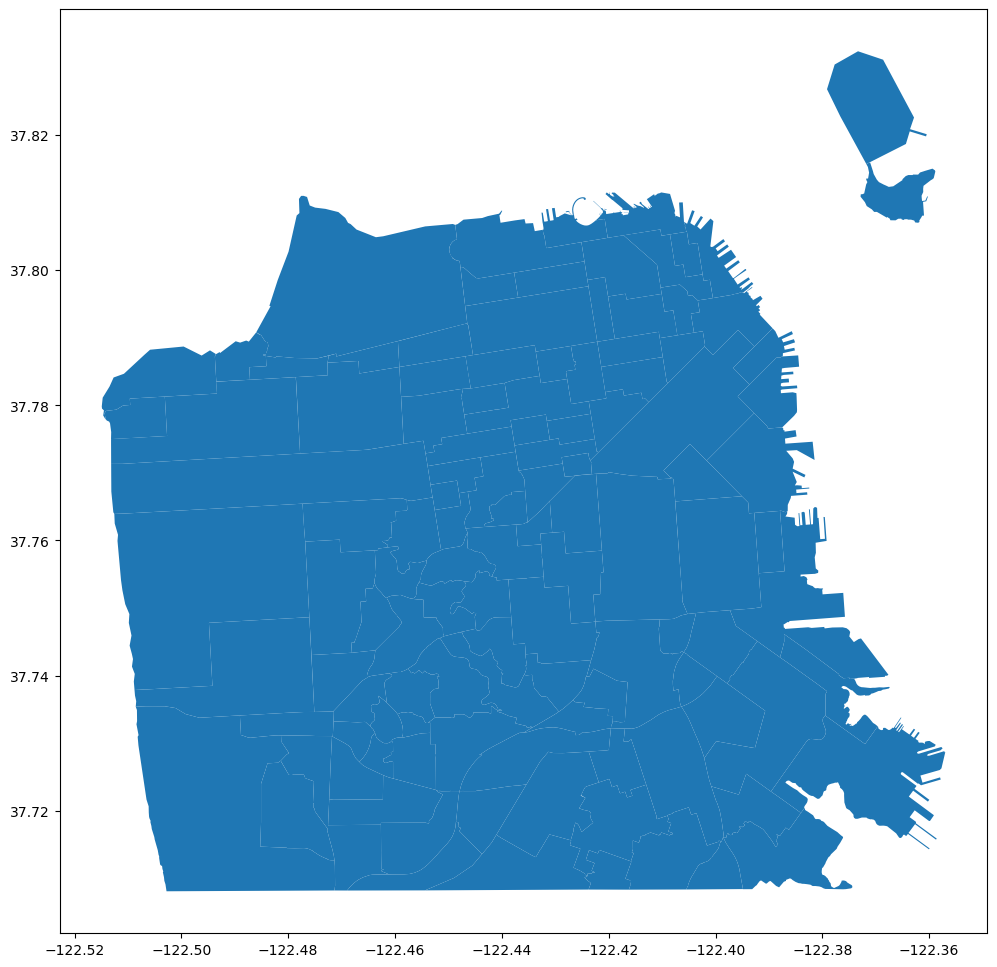

In [136]:
# maps neighborhoods 
hoods.plot(figsize=(12,12))

In [138]:
# spatial join transportation to neighborhoods 
transport_by_hood = gpd.sjoin(hoods, transport) #Spatial join points to polygons

# verify 
transport_by_hood.head(5)

,link,name,geometry,index_right,FIPS,Total Population,"Car, Truck, or Van",Drove Alone,Carpooled,Public Transportation,Motorcycle,Bicycle,Walked,Other Means,Worked At Home,Non-Private Transport
0,"http://en.wikipedia.org/wiki/Sea_Cliff,_San_Fr...",Seacliff,"MULTIPOLYGON (((-122.49346 37.78352, -122.4937...",115,6075042700,5365,1704,1160,544,573,0,50,125,16,538,1308
0,"http://en.wikipedia.org/wiki/Sea_Cliff,_San_Fr...",Seacliff,"MULTIPOLYGON (((-122.49346 37.78352, -122.4937...",26,6075042601,3999,719,700,19,547,24,39,60,66,573,731
0,"http://en.wikipedia.org/wiki/Sea_Cliff,_San_Fr...",Seacliff,"MULTIPOLYGON (((-122.49346 37.78352, -122.4937...",37,6075980200,179,0,0,0,0,0,0,0,0,0,0
0,"http://en.wikipedia.org/wiki/Sea_Cliff,_San_Fr...",Seacliff,"MULTIPOLYGON (((-122.49346 37.78352, -122.4937...",116,6075042800,2419,535,473,62,77,0,19,54,0,526,212
0,"http://en.wikipedia.org/wiki/Sea_Cliff,_San_Fr...",Seacliff,"MULTIPOLYGON (((-122.49346 37.78352, -122.4937...",123,6075060100,3808,943,839,104,188,0,128,173,36,548,629


<Axes: >

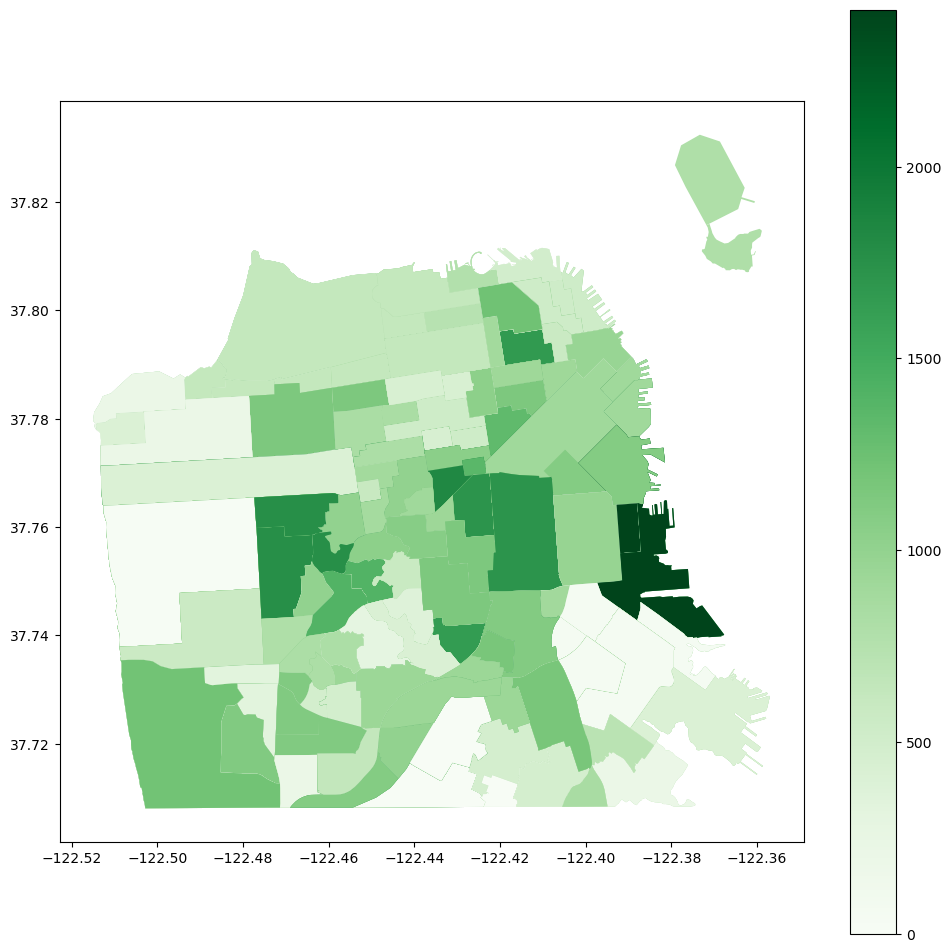

In [141]:
# choropleth map of arrests by neighborhood
fig,ax = plt.subplots(figsize=(12,12)) # empty plot

transport_by_hood.plot(ax=ax,column='Non-Private Transport',legend=True,cmap='Greens')

## Next Steps 

* merge neighbhoods to show total count per neighborhood
* make this interactive so i can hover over the neighborhood to get information
* add title
* explain how this contributes to the project 

In [148]:
# count the number of public transit users per community
transit_users_by_hood = transport_by_hood.value_counts('name').reset_index(name='transit_users')
# we are disolving on the value in 'name' column. and changing it to arrest_count
transit_users_by_hood

,name,transit_users
0,Golden Gate Park,22
1,Mission,21
2,Pacific Heights,20
3,South of Market,18
4,Outer Sunset,18
...,...,...
112,St. Francis Wood,2
113,Westwood Highlands,2
114,Balboa Terrace,1
115,Treasure Island,1
